                                          TASK 2 MOVIE RATING PREDICTION WITH PYTHON

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("IMDb Movies India.csv", encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [7]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [31]:
df = df.dropna(subset=['Rating'])

print("After removing missing Ratings:")
print(df['Rating'].isnull().sum())
print("Total rows:", df.shape[0])

After removing missing Ratings:
0
Total rows: 7919


In [33]:
df.fillna("Unknown", inplace=True)

print("Missing values after fillna:")
print(df.isnull().sum())

Missing values after fillna:
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


In [35]:
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
df['Votes'] = df['Votes'].fillna(df['Votes'].median())

print("Votes column info:")
print(df['Votes'].head())
print("Missing in Votes:", df['Votes'].isnull().sum())

Votes column info:
1      8.0
3     35.0
5    827.0
6     35.0
8    326.0
Name: Votes, dtype: float64
Missing in Votes: 0


In [41]:
print(df.columns)

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')


In [43]:
print(df['Duration'].dtype)

float64


In [45]:
# Convert Duration safely to string first
df['Duration'] = df['Duration'].astype(str)

# Remove 'min' or ' min' if present
df['Duration'] = df['Duration'].str.replace('min', '', regex=False)
df['Duration'] = df['Duration'].str.strip()

# Convert to numeric
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

# Fill missing values with median
df['Duration'] = df['Duration'].fillna(df['Duration'].median())

print("Duration column info:")
print(df['Duration'].head())
print("Missing in Duration:", df['Duration'].isnull().sum())

Duration column info:
1    109.0
3    110.0
5    147.0
6    142.0
8     82.0
Name: Duration, dtype: float64
Missing in Duration: 0


In [47]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')


In [51]:
df[['Genre','Director','Actor 1','Actor 2','Actor 3']] = \
df[['Genre','Director','Actor 1','Actor 2','Actor 3']].fillna("Unknown")

In [53]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])
df['Director'] = le.fit_transform(df['Director'])
df['Actor 1'] = le.fit_transform(df['Actor 1'])
df['Actor 2'] = le.fit_transform(df['Actor 2'])
df['Actor 3'] = le.fit_transform(df['Actor 3'])

print(df[['Genre','Director','Actor 1','Actor 2','Actor 3']].head())

   Genre  Director  Actor 1  Actor 2  Actor 3
1    268       811     1782     2815      377
3    207      1749     1589      890     2572
5    177      2005      508       85     2449
6    331      2643      931     1388     3030
8    367       174     2521     1461     1205


In [19]:
X = df[['Duration', 'Votes', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']]
y = df['Rating']

print(X.head())
print(y.head())

   Duration  Votes  Genre  Director  Actor 1  Actor 2  Actor 3
1     109.0    8.0    268       811     1782     2815      377
3     110.0   35.0    207      1749     1589      890     2572
5     147.0  827.0    177      2005      508       85     2449
6     142.0   35.0    331      2643      931     1388     3030
8      82.0  326.0    367       174     2521     1461     1205
1    7.0
3    4.4
5    4.7
6    7.4
8    5.6
Name: Rating, dtype: float64


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (6335, 7)
Testing size: (1584, 7)


In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [25]:
y_pred = model.predict(X_test)

print("Predicted Ratings (first 10):")
print(y_pred[:10])

Predicted Ratings (first 10):
[6.01435802 5.65519103 5.52853787 5.89672704 6.08623607 5.61788373
 6.00350471 5.98457097 5.81767528 5.99568889]


In [27]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 1.0775256397431607
Mean Squared Error: 1.7919785062341402
R2 Score: 0.036127698123226026


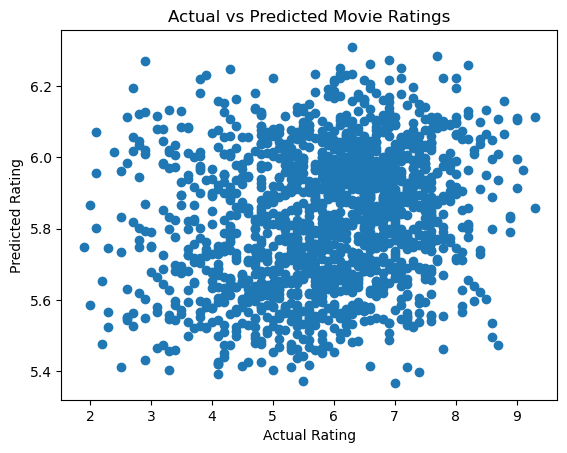

In [29]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")
plt.show()